# Supplementary Figures S19–S24: ARISTA

This notebook recalculates S23 and S24 from all 531 ligand–receptor time courses, selects 25 representative pairs per cluster, and draws both figures. For S19–S22, it lists the original calculation and rendering files and shows the completed pages because some layout inputs are stored with the paper results rather than the installed package.

The same redraw can be run after installation with `cytobridge figure arista-lr --output-dir outputs/arista_lr`.

## How this figure is made

Follow the steps from top to bottom. Each command names its input, the files it
creates, and the calculation that uses those files next.

Replace text inside angle brackets with your path or value. For example,
`<output-dir>` means the directory where you want the files to be written.

### 1. run ARISTA downstream

Used for: S19-S24

```text
cytobridge workflow --config arista --step downstream --aligned-h5ad <aligned.h5ad> --model-dir <training> --output-dir <downstream>
```

Input: `paper aligned H5AD and training directory`

Creates: `spatial snapshots; growth; composition; gene_dynamics/*.csv; ligand_receptor/pair_timecourse.csv; coverage and pattern tables`

Continue with: `build corrected ARISTA figures`

### 2. draw interpolation, growth, lineage/composition, and gene programs

Used for: S19-S22

```text
ARISTA renderers in release_artifacts/arista_package_native_spatialqc_z50_retrain_20260824_r1
```

Input: `downstream slice H5ADs, growth, composition, gene-dynamics and GO tables`

Creates: `corrected vector PDF/PNG pages plus run records`

Continue with: `finished S19-S22`

### 3. recluster all LR profiles and draw S23-S24

Used for: S23-S24

```text
python scripts/execute_paper_notebooks.py --notebook arista_figures --output-dir <notebook-run>
```

Input: `ligand_receptor_all_pair_timecourse.csv (531 pairs × 9 times)`

Creates: `k-selection, assignments, prototypes, balanced display roster, displayed time courses, and the S23-S24 PDF/PNG files`

Continue with: `finished figures`

### 4. draw corrected LR figures

Used for: S23-S24

The notebook command in the preceding step calls the plotting function after calculating the LR tables.

Input: `calculated LR tables from the previous step`

Creates: `Supplementary_Figure_S23.pdf/.png; Supplementary_Figure_S24.pdf/.png`

Continue with: `finished figure`

## Setup

In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    calculate_arista_ligand_receptor_panels,
    export_arista_reference_pages,
    load_arista_supplementary_figures,
    plot_arista_ligand_receptor_figures,
    write_arista_ligand_receptor_tables,
)

output_dir = Path("outputs") / "arista_supplementary_figures"
reference_dir = output_dir / "reference_pages"
output_dir.mkdir(parents=True, exist_ok=True)
data = load_arista_supplementary_figures()
data.figure_index[["figure", "topic"]]

,figure,topic
0,S19,Spatial interpolation
1,S20,Growth
2,S21,Lineage and composition
3,S22,Gene programs and GO enrichment
4,S23,Ligand-receptor clusters
5,S24,Ligand-receptor small multiples


## Calculate S23 and S24 from all released LR time courses

In [2]:
panels = calculate_arista_ligand_receptor_panels(data)
{
    "input_profiles": len(panels.assignments),
    "cluster_sizes": panels.prototypes.groupby("cluster")["n_pairs"].first().astype(int).to_dict(),
    "displayed_per_cluster": panels.display_roster.groupby("cluster").size().astype(int).to_dict(),
    "selected_k": int(panels.k_selection.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"]),
}

{'input_profiles': 531,
 'cluster_sizes': {1: 217, 2: 314},
 'displayed_per_cluster': {1: 25, 2: 25},
 'selected_k': 2}

## Draw S23 and S24 from the calculated tables

In [3]:
figures = plot_arista_ligand_receptor_figures(data, output_dir, panels)
tables = write_arista_ligand_receptor_tables(data, output_dir, panels)
{
    figure: {"pdf": paths[0].name, "png": paths[1].name}
    for figure, paths in figures.items()
}

{'S23': {'pdf': 'FigureS23_ARISTA_redrawn.pdf',
  'png': 'FigureS23_ARISTA_redrawn.png'},
 'S24': {'pdf': 'FigureS24_ARISTA_redrawn.pdf',
  'png': 'FigureS24_ARISTA_redrawn.png'}}

## Preview the table-driven scientific redraws

S23


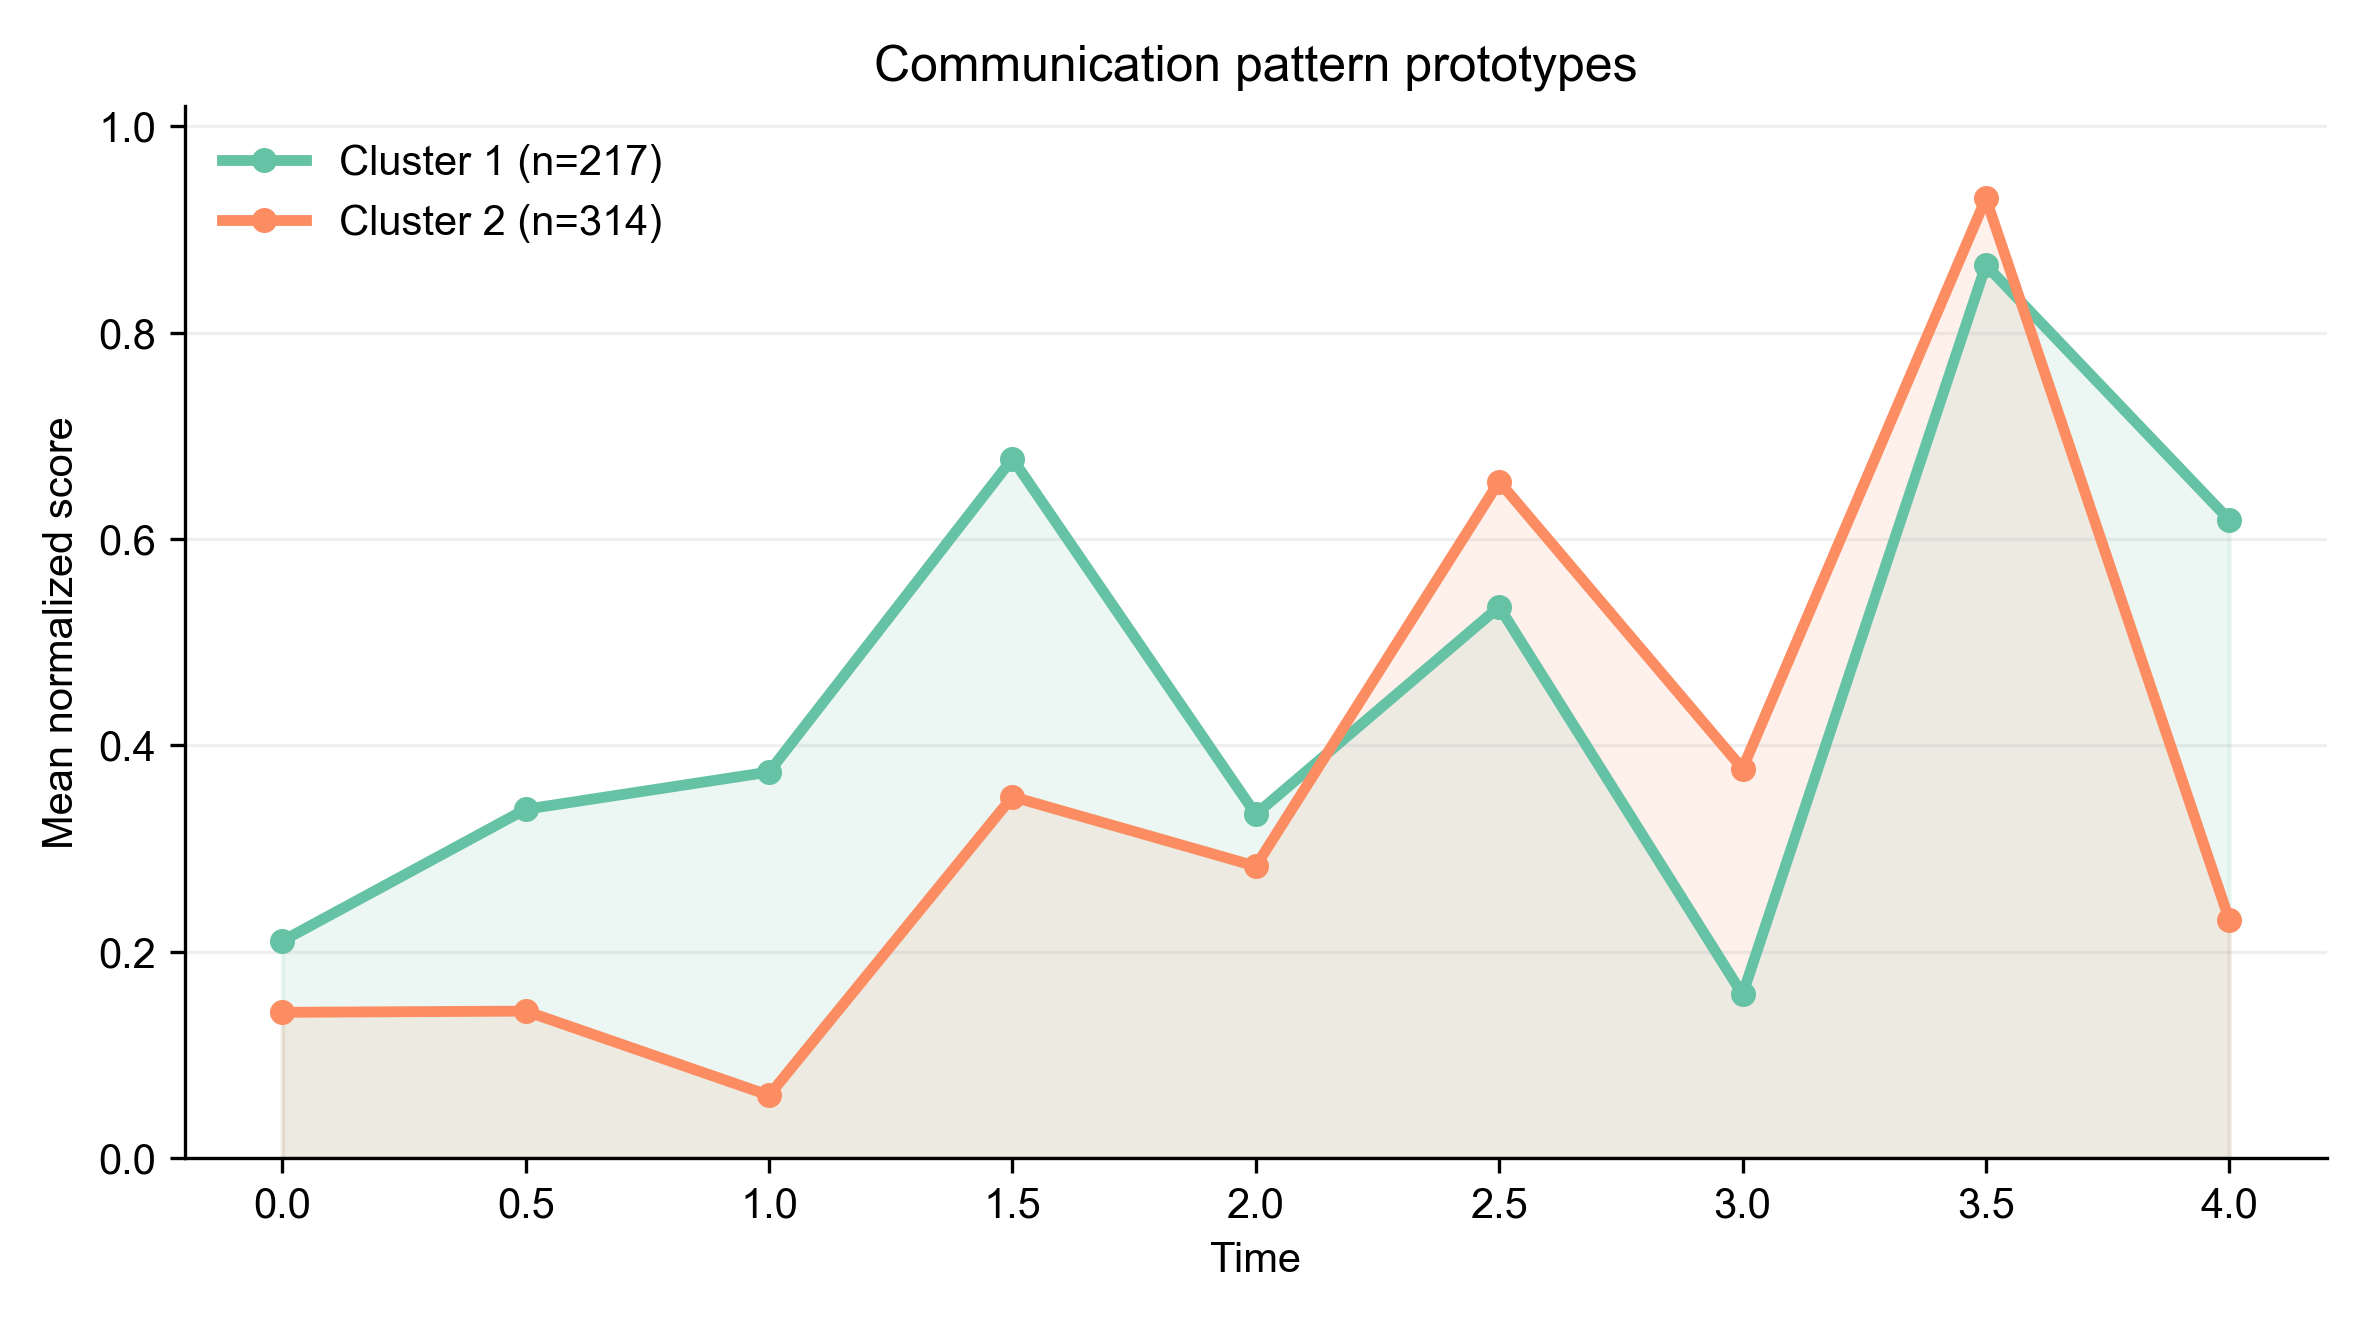

S24


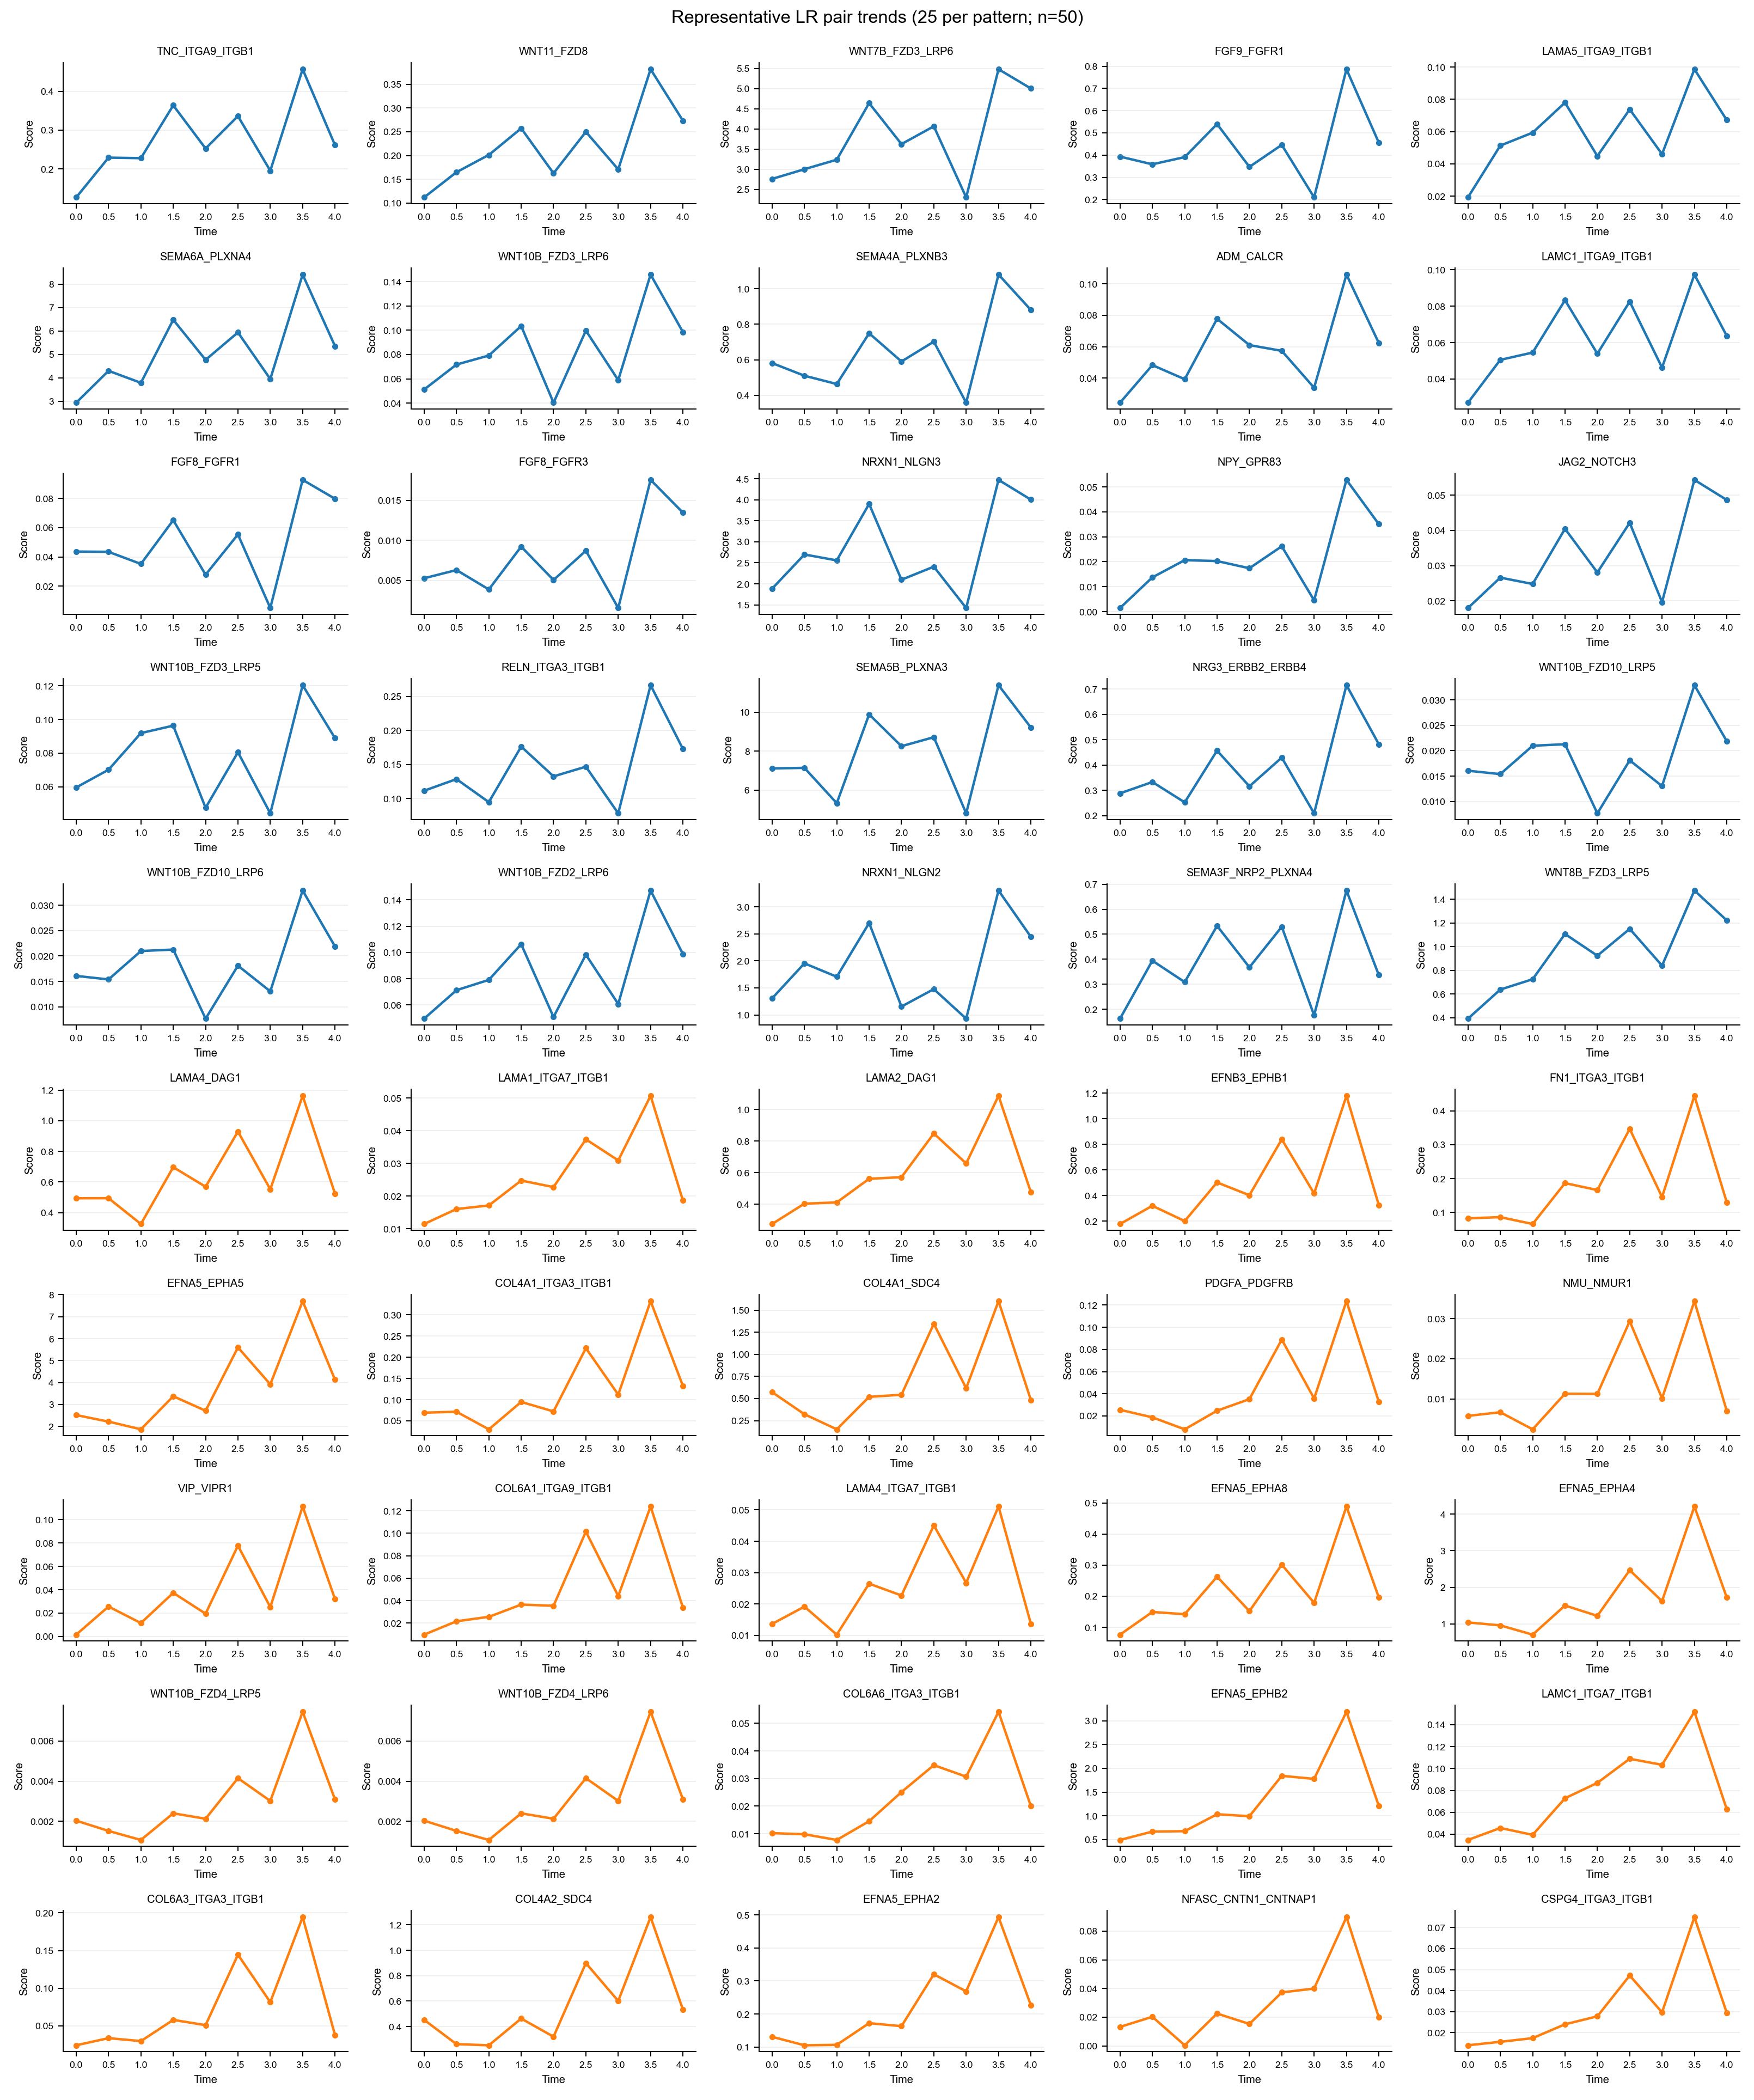

In [4]:
for figure, (_, png_path) in figures.items():
    print(figure)
    display(Image(filename=str(png_path), width=720))

## Released reference pages for S19–S22

In [5]:
reference_pages = export_arista_reference_pages(
    data,
    reference_dir,
    figures=("S19", "S20", "S21", "S22"),
)
{figure: paths[1].name for figure, paths in reference_pages.items()}

{'S19': 'FigureS19_ARISTA_interpolation.png',
 'S20': 'FigureS20_ARISTA_growth.png',
 'S21': 'FigureS21_ARISTA_lineage_composition.png',
 'S22': 'FigureS22_ARISTA_gene_programs_GO.png'}

## Source files for the complete pages

In [6]:
display(
    data.full_recompute_inputs[["input_id", "stage", "figures"]]
)

,input_id,stage,figures
0,raw_h5ad,download,S19;S20;S21;S22;S23;S24
1,aligned_h5ad,generated,S19;S20;S21;S22;S23;S24
2,model_dir,generated,S19;S20;S21;S22;S23;S24
3,slice_dir,generated,S19;S20
4,growth_by_cell,generated,S20
5,fixed_particle_composition,generated,S21
6,gene_mean_expression,generated,S22
7,gene_reconstruction_diagnostics,generated,S22
8,go_biological_process_gmt,download,S22
9,lr_pair_timecourse,generated,S23;S24
